# Experiment 01: DP-SGD vs Standard SGD on Patient Health Data

In this experiment, we transition from dummy tensors to a real-world tabular dataset (`sample.csv`). Our objective is to predict a patient's **COVID-19 history** based on their health metrics, demographics, and pre-existing conditions.

We will:
1. Preprocess the dataset (handling strings, categories, and numerical scaling).
2. Train a baseline, **Non-DP** Neural Network to establish a utility benchmark.
3. Train a **Differentially Private** Neural Network using Opacus.
4. Compare the accuracy and loss to observe the **Utility vs. Privacy Tradeoff**.

In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from opacus import PrivacyEngine
import matplotlib.pyplot as plt

# Set seeds for reproducibility
torch.manual_seed(42)
import random; random.seed(42)
import numpy as np; np.random.seed(42)

## 1. Data Loading and Preprocessing

Real-world data is messy. We need to strip perdonally identifiable information (PII), handle formating quirks (e.g., blood pressure strings), and encode our categorical text.

In [2]:
# load data
df = pd.read_csv(r'data/sample.csv')
df.head(5)

,patient_ID,name,Age,sex,location,blood_group,sexual_status,bp_rate(mmHg),heart_rate(bpm),diabetes,thyroid,cardiac_issue,asthma,surgery,surgery_desc,other,covid_history
0,P0813,Alex Rivers,28,F,Boston,B+,active,127/88,78,0,no,0,1,1,gall bladder stone removal,hyponatremia and gastritis,yes
1,P0238,Honda Daisuke,39,M,Osaka,0+,active,135/89,66,0,hyper,1,0,1,open heart surgery,migrane,no
2,P0562,Raymond Murphy,26,M,London,O+,inactive,128/82,82,0,hypo,0,1,1,cryosurgery for warts in hand,fatty liver and hypertyension,yes
3,P0110,Gyortske Kvala,26,M,Helsinki,A-,active,123/89,76,0,no,1,1,1,vulva surgery,erectile disfunctionality and dust allergy,no
4,P0549,Xiao Wu,43,F,Kunming,A+,inactive,134/89,92,1,hypo,0,1,0,NaN,hypertension and iron deficiency,no


In [3]:
""" Dataset Preprocessing"""

# 1. Dropp PII and unstructured text to protect raw identity (First line of privacy!)
df = df.drop(columns=['patient_ID', 'name', 'surgery_desc', 'other'])

# 2. Parse Blood Pressure '127/88' --> systolic, diastolic
df[['systolic', 'diastolic']] = df['bp_rate(mmHg)'].str.split('/', expand=True).astype(float)
df = df.drop(columns=['bp_rate(mmHg)'])

# 3. Encode Target Variable (covid_history)
df['covid_history'] = df['covid_history'].map({'yes': 1, 'no': 0})

# 4. One-Hot Encode Categorical Features
cat_cols = ['sex', 'location', 'blood_group', 'sexual_status', 'thyroid']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# 5. Split features and target
X = df.drop(columns=['covid_history']).values.astype(np.float32)
y = df['covid_history'].values.astype(np.float32).reshape(-1, 1)

In [4]:
""" Train and test Split"""
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
# 6. Scale Numerical Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [6]:
# 7. Convert to PyTorch Tensors & DataLoaders
train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

In [7]:
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

input_dim = X_train.shape[1]
print(f"Training Smaples: {X_train.shape[0]} | Features: {input_dim}")

Training Smaples: 124 | Features: 144


## 2. Model Architecture

We will define a simple Multi-Layer Perceptron (MLP) suitable for binary classification. We will instantiate two copies: one for baseline training, and one for DP training.

In [8]:
class PatientClassifier(nn.Module):
    def __init__(self, input_dim):
        super(PatientClassifier, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.net(x)
    
def calculate_accuracy(preds, labels):
    predictions = (preds >= 0.5).float()
    return (predictions == labels).float().mean().item()

## 3. Baseline Training (No Privacy)

Now, let's train a standard model without DP to see the best possible accuracy our model can achieve on this data without DP.

In [9]:
from tqdm import tqdm

EPOCHS = 20
LR = 0.05

model_baseline = PatientClassifier(input_dim)
optimizer_baseline = optim.SGD(model_baseline.parameters(), lr=LR)
criterion = nn.BCELoss()

print("=== Training Baseline Model ===")
baseline_accs = []

for epoch in range(EPOCHS):
    model_baseline.train()
    epoch_acc = []

    # tqdm for batch loop
    for x_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        optimizer_baseline.zero_grad()
        preds = model_baseline(x_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer_baseline.step()

        epoch_acc.append(calculate_accuracy(preds, y_batch))

    baseline_accs.append(np.mean(epoch_acc))
    
model_baseline.eval()
with torch.no_grad():
    test_preds = model_baseline(torch.tensor(X_test))
    baseline_test_acc = calculate_accuracy(test_preds, torch.tensor(y_test))
    
print(f"Baseline Test Accuracy: {baseline_test_acc * 100:.2f}%")

=== Training Baseline Model ===


Epoch 20: 100%|████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 1778.28it/s]

Baseline Test Accuracy: 65.62%


## 4. Differentially Private Training

Now, we apply Opacus. We will wrap the model, optimizer, and dataloader with the `PrivacyEngine`. 

In [10]:
model_dp = PatientClassifier(input_dim)
optimizer_dp = optim.SGD(model_dp.parameters(), lr=LR)

privacy_engine = PrivacyEngine()
model_dp, optimizer_dp, train_loader_dp = privacy_engine.make_private(
    module=model_dp,
    optimizer=optimizer_dp,
    data_loader=train_loader,
    noise_multiplier=1.2, # Adds Noise
    max_grad_norm=1.0,
)

DELTA = 1e-5

print("\n=== Training DP Model ===")
dp_accs = []
for epoch in range(EPOCHS):
    model_dp.train()
    epoch_acc = []
    
    # tqdm for batch loop
    for x_batch, y_batch in tqdm(train_loader_dp, desc=f"Epoch {epoch+1}"):
        optimizer_dp.zero_grad()
        preds = model_dp(x_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer_dp.step()
        
        epoch_acc.append(calculate_accuracy(preds, y_batch))
        
    dp_accs.append(np.mean(epoch_acc))
    epsilon = privacy_engine.get_epsilon(delta=DELTA)

model_dp.eval()
with torch.no_grad():
    test_preds_dp = model_dp(torch.tensor(X_test))
    dp_test_acc = calculate_accuracy(test_preds_dp, torch.tensor(y_test))

print(f"DP Test Accuracy: {dp_test_acc * 100:.2f}%")
print(f"\n\tFinal Privacy Budget spent: ε = {epsilon:.2f}")

C:\Users\MUBASHIR MOHSIN\AppData\Roaming\Python\Python39\site-packages\opacus\privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(



=== Training DP Model ===


Epoch 20: 100%|█████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 615.32it/s]

DP Test Accuracy: 62.50%

	Final Privacy Budget spent: ε = 8.21


## 5. Visualizing the Utility Loss
Because DP adds noise to gradients, the model's convergence is generally noisier and the final accuracy is slightly lower. Let's look at the training accuracy over epochs to observe this tradeoff.

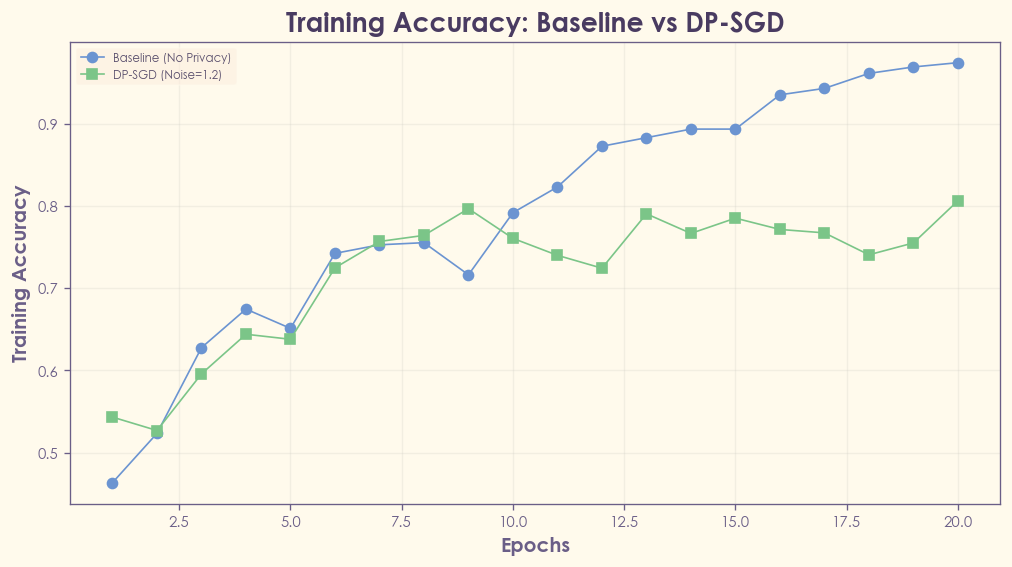


=== Summary ===
Utility Loss (Test Accuracy Difference): 3.12%


In [11]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS+1), baseline_accs, label='Baseline (No Privacy)', marker='o')
plt.plot(range(1, EPOCHS+1), dp_accs, label='DP-SGD (Noise=1.2)', marker='s')
plt.title('Training Accuracy: Baseline vs DP-SGD')
plt.xlabel('Epochs')
plt.ylabel('Training Accuracy')
plt.legend()
plt.grid(True)
plt.show()

print("\n=== Summary ===")
print(f"Utility Loss (Test Accuracy Difference): {(baseline_test_acc - dp_test_acc) * 100:.2f}%")

## 6. Analysis and Observations

### The Training Dynamics (Visual Observation)
Looking at the training accuracy plot, there is a stark visual contrast between the two models:
* **The Baseline (Blue Line):** Exhibits a smooth, steady convergence, quickly climbing and stabilizing at a high training accuracy. This represents standard, unhindered gradient descent.
* **The DP-SGD (Green Line):** Is highly volatile and struggles to reach the same training peaks, jaggedly fluctuating throughout the 20 epochs. 

> **Why this happens:** This volatility is the direct visual manifestation of the `PrivacyEngine` at work. During each step, gradients are being artificially clipped (restricted in magnitude via `max_grad_norm`) and obfuscated with Gaussian noise (via `noise_multiplier=1.2`). The optimizer is no longer taking the most efficient path down the loss gradient; it is taking a noisy, constrained path to prevent memorization of individual data points.
<br><br>

### The Utility-Privacy Tradeoff
Our final test metrics quantify the cost of privacy for this specific dataset:
* **Baseline Accuracy:** 65.62%
* **DP-SGD Accuracy:** 62.50%
* **Utility Loss:** 3.12%
* **Privacy Budget Expended:** 𝜖 = 8.21

A privacy budget of 𝜖 = 8.21$ is a moderate guarantee. In practice, achieving single-digit epsilon values while only sacrificing ~3\% test accuracy demonstrates a successful application of DP-SGD. The model was forced to learn the generalized population trends regarding COVID-19 history rather than memorizing the specific outliers or unique health combinations of individual patients.

### Why is this Trade-off Viable?
In the context of the privacy-preserving medical data, a 3.12\% drop in accuracy is not just viable; it is often mandatory for real-world deployment. Here is why:

1. **Mitigating Membership Inference:** Medical datasets contain highly sensitive indicators (blood pressure, surgeries, specific comorbidities). Without DP, a malicious actor could query the baseline model and reverse-engineer whether a specific individual was part of the training set. DP mathematically bounds this risk.
2. **Regulatory Compliance vs. Deployment:** A baseline model with 65.62% accuracy that leaks patient data cannot legally or ethically be deployed under strict frameworks like HIPAA or GDPR. A slightly less accurate model (62.50%) that guarantees cryptographic privacy **CAN** be deployed. 
3. **Generalization over Memorization:** The noise injected by DP acts as a strong regularizer. While it harms training accuracy heavily, it often forces the model to generalize better on unseen data, which explains why our test accuracy only dropped by ~3% despite the wildly unstable training curve.